例 12.3 表 12.2 是 Malinvand 于 1966 年提出的研究法国经济问题的一组数据. 所考虑的因变量为进口总额 $y$, 三个解释变量分别为: 国内总产值 $x_1$、储存量 $x_2$、总消费量 $x_3$ (单位均为 10 亿法郎).

表 12.2 1949～1959 年法国进口总额与相关变量的数据

| 年份 | $x_1$  | $x_2$ | $x_3$  | $y$  | 年份 | $x_1$  | $x_2$ | $x_3$  | $y$  |
| ---- | ------ | ----- | ------ | ---- | ---- | ------ | ----- | ------ | ---- |
| 1949 | 149.3  | 4.2   | 108.1  | 15.9 | 1955 | 202.1  | 2.1   | 146.0  | 22.7 |
| 1950 | 171.5  | 4.1   | 114.8  | 16.4 | 1956 | 212.4  | 5.6   | 154.1  | 26.5 |
| 1951 | 175.5  | 3.1   | 123.2  | 19.0 | 1957 | 226.1  | 5.0   | 162.3  | 28.1 |
| 1952 | 180.8  | 3.1   | 126.9  | 19.1 | 1958 | 231.9  | 5.1   | 164.3  | 27.6 |
| 1953 | 190.7  | 1.1   | 132.1  | 18.8 | 1959 | 239.0  | 0.7   | 167.6  | 26.3 |
| 1954 | 202.1  | 2.2   | 137.7  | 20.4 |      |        |       |        |      |

对于上述问题, 可以直接用普通的最小二乘估计建立 $y$ 关于三个解释变量 $x_1, x_2$ 和 $x_3$ 的回归方程为

$$y = -8.6203 - 0.0742x_1 + 0.5104x_2 + 0.3116x_3,$$

并且模型的统计检验指标都相当好, 但是 $x_1$ 的系数为负, 这不符合经济意义, 因为法国是一个原材料进口国, 当国内总产值 $x_1$ 增加时, 进口总额 $y$ 也应该增加, 所以该系数的符号应该为正. 其原因就是三个自变量 $x_1, x_2$ 和 $x_3$ 之间存在多重共线性.

$x_1, x_2$ 和 $x_3$ 三者的相关系数矩阵

$$\boldsymbol{R} = \begin{bmatrix} 1 & -0.0329 & 0.9869 \\ -0.0329 & 1 & 0.0357 \\ 0.9869 & 0.0357 & 1 \end{bmatrix},$$

由此可知 $x_1$ 与 $x_3$ 间的相关系数高达 0.9869, 这说明 $x_1$ 与 $x_3$ 基本线性相关, 若将 $x_3$ 看作因变量, $x_1$ 看作解释变量, 那么 $x_3$ 关于 $x_1$ 的一元线性回归方程为

$$x_3 = -4.9632 + 0.7297x_1.$$

这说明当 $x_1$ 变化时, $x_3$ 不可能保持一个常数, 因此对回归系数的解释就复杂了, 不能仅从其符号上作解释, $x_1$ 和 $x_3$ 之间存在着多重共线性关系.

In [ ]:
import numpy as np
import statsmodels.api as sm
import warnings

# 过滤特定警告
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", message="kurtosistest only valid for n>=20 ... continuing anyway, n=.*")

a = np.loadtxt("Pdata12_3.txt")
x = a[:, :3]  # 提取自变量观测值矩阵
X = sm.add_constant(x)  # 增加常数项

md = sm.OLS(a[:, 3], X).fit()

b = md.params  # 回归系数
y = md.predict(X)  # 预测值

print(md.summary())  # 模型结果
print()
print(f"相关系数矩阵:\n{np.corrcoef(x.T)}")

# 一元回归(x1对x3)
X1 = sm.add_constant(a[:, 0])  
md1 = sm.OLS(a[:, 2], X1).fit()
print()
print(f"回归系数为:{md1.params}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     542.0
Date:                Sat, 16 Aug 2025   Prob (F-statistic):           1.20e-08
Time:                        12:55:58   Log-Likelihood:                -1.7480
No. Observations:                  11   AIC:                             11.50
Df Residuals:                       7   BIC:                             13.09
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.6203      0.897     -9.611      0.0

“多重共线性”一词由 R. Frisch 在 1934 年提出的, 它原指模型的解释变量间存在线性关系. 在实际经济问题中, 由于经济变量本身的性质, 多重共线性是存在于计量经济学模型中的一个普遍的问题, 产生多重共线性的原因一般有以下三种情况:

(1) 许多**经济变量**之间存在着相关关系, **有着共同的变化趋势**, 例如, 国民经济发展使国民增加了收入, 随之消费、储蓄和投资出现了共同增长. 当这些变量同时进入模型后就会带来多重共线性问题. 如果采用其中的两个作为解释变量, 就可能产生多重共线性问题.

(2) 在回归模型中**使用滞后解释变量**, 也可能产生多重共线性问题, 由于经济变量的现期值和各滞后期值往往高度相关. 因此使用滞后解释变量所形成的分布滞后模型就存在一定程度的多重共线性.

(3) **样本数据**也会引起多重共线性问题. 根据回归模型的假设, 解释变量是非随机变量, 由于收集的数据过窄而造成某些解释变量似乎有相同或相反的变化趋势, 也就是说解释变量即使在总体上不存在线性关系, 其样本也可能是线性相关的. 在此意义上说, 多重共线性是一种样本现象.

一般地, 关于多重共线性关系, 给出如下定义.

定义 12.1 当设计矩阵 $\boldsymbol{X}$ 的列向量间具有近似的线性相关时, 即存在不全为 0 的常数 $c_0, c_1, \cdots, c_m$, 使得 $c_0 + c_1 x_1 + \cdots + c_m x_m \approx 0$, 称各自变量之间有多重共线性关系.

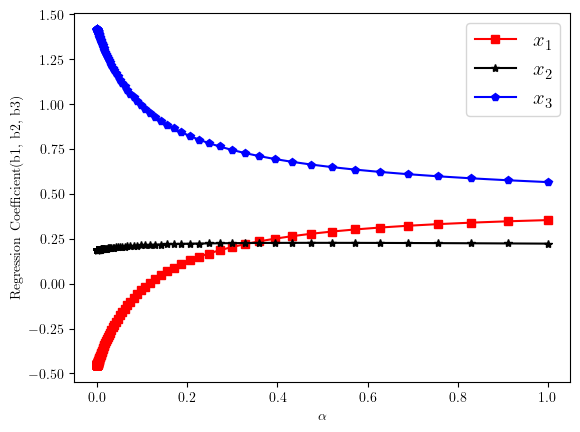

最优的正则化系数alpha: 0.001788649529057435
标准化数据的所有回归系数为: [0.25175125 0.2261851  0.6902453 ]
原始数据的回归系数(截距, array(斜率))为:
[-9.532026187037477, array([0.04098598, 0.62314057, 0.15199106])]
拟合优度(复判定系数): 0.9843368597895965


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from scipy.stats import zscore

a = np.loadtxt("Pdata12_3.txt")
n = a.shape[1] - 1  # 自变量的总个数    
aa = zscore(a)  # 中心标准化

x = aa[:, :n]  # 自变量观测值矩阵
y = aa[:, n]  # 因变量观测值矩阵(向量)

b = []  # 用于存储回归系数的空列表
kk = np.logspace(-4, 0, 100)  # 循环迭代的不同k值,logspace默认以10为底,从10^-4 ~ 10^0的100个数
for k in kk:
    md = Ridge(alpha=k).fit(x, y)
    b.append(md.coef_)  # 100个alpha的回归参数(k),列表100各元素每一个都是一个array
    
st = ['s-r', '*-k', 'p-b']  # 画图曲线样式
plt.rcParams['text.usetex'] = True
plt.rcParams['font.sans-serif'] = ['SimHei']

for i in range(3):
    plt.plot(kk, np.array(b)[:, i], st[i])  # np.array(b)(100, 3),每列都是x_i对应的100个alpha的系数值
plt.legend(['$x_1$', '$x_2$', '$x_3$'], fontsize=15)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'Regression Coefficient(b1, b2, b3)')
plt.show()

# Ridge cross-validation内置交叉验证，自动选择最佳正则化参数
mdcv = RidgeCV(alphas=np.logspace(-4, 0, 100)).fit(x, y)  
print(f"最优的正则化系数alpha: {mdcv.alpha_}")
# md0 = Ridge(mdcv.alpha_).fit(x, y)  # 最优的alpha拟合, R^2=0.9957
# 看图，岭迹法手动选择alpha
md0 = Ridge(0.4).fit(x, y)  # alpha=0.4拟合，R^2=0.98434

cs0 = md0.coef_  # 提出标准化数据的回归系数b1, b2, b3, (3,)
print(f"标准化数据的所有回归系数为: {cs0}")

mu = np.mean(a, axis=0)  # (4,), axis=0 计算列

# ddof:自由度修正值(默认ddof=0)。
# ddof=0:计算总体标准差(除以N)。
# ddof=1:计算样本标准差(除以N-1，更常用在统计分析中)
s = np.std(a, axis=0, ddof=1)  # 计算所有指标的均值和标准差
# 由标准化公式反推, beta0(截距intercept)=mu_y-s_y*(b_i*mu_i/s_i), beta_i(i>=1)=s_y*b_i/s_i
params = [mu[-1] - s[-1] * sum(cs0 * mu[:-1] / s[:-1]), s[-1] * cs0 / s[:-1]]
print(f"原始数据的回归系数(截距, array(斜率))为:\n{params}")
print(f"拟合优度(复判定系数): {md0.score(x, y)}")


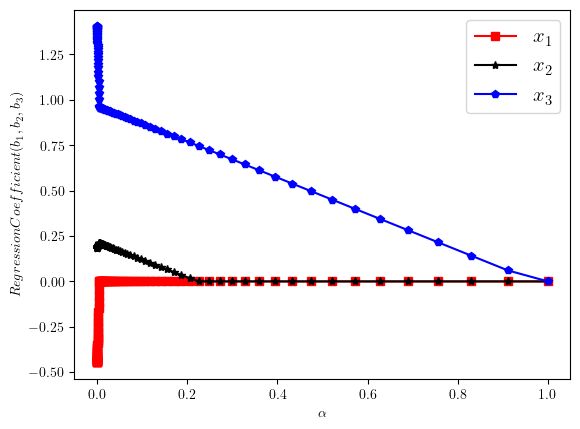

最优alpha=0.0001
标准化数据的回归系数为: [-0.44555416  0.18586692  1.40485795]
原始数据的回归系数为: [-8.641136992582023, array([-0.07253777,  0.51206386,  0.30934779])]
拟合优度为: 0.9957110381477524


In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LassoCV
from scipy.stats import zscore

a = np.loadtxt("Pdata12_3.txt")
n = a.shape[1] - 1  # 自变量的总个数    
aa = zscore(a)  # 中心标准化

x = aa[:, :n]
y = aa[:, n]

b=[]
kk = np.logspace(-4, 0, 100)
for k in kk:
    md = Lasso(alpha=k).fit(x, y)
    b.append(md.coef_)

st = ['s-r', '*-k', 'p-b']
for i in range(3):
    plt.plot(kk, np.array(b)[:, i], st[i])
plt.legend(['$x_1$', '$x_2$', '$x_3$'], fontsize=15)
plt.xlabel(r'$\alpha$')
plt.ylabel('$Regression Coefficient(b_1, b_2, b_3)$')
plt.show()

# 交叉验证Lasso回归
mdcv = LassoCV(alphas=np.logspace(-4, 0, 100)).fit(x, y)
print(f"最优alpha={mdcv.alpha_}")

md0 = Lasso(mdcv.alpha_).fit(x, y)  # 0.9957
# md0 = Lasso(alpha=0.21).fit(x, y)  # R^2=0.9061
cs0 = md0.coef_
print(f"标准化数据的回归系数为: {cs0}")

mu = np.mean(a, axis=0)
s = np.std(a, axis=0, ddof=1)

params = [mu[-1] - s[-1] * sum(cs0 * mu[:-1] / s[:-1]), s[-1] * cs0 / s[:-1]]

print(f"原始数据的回归系数为: {params}")
print(f"拟合优度为: {md0.score(x, y)}")

解 画出的 $k$ 与 LASSO 回归系数的关系图如图 12.2 所示, 从图中可以看出选 $k = 0.21$ 较好. 对应的标准化 LASSO 回归方程为

$$\hat{y}^* = 0.0136x_2^* + 0.7614x_3^*,$$

将标准化回归方程还原后得

$$\hat{y} = -1.6602 + 0.0374x_2 + 0.1677x_3,$$

模型的拟合优度 $R^2 = 0.9061$. 从计算结果可以看出, LASSO 回归可以非常方便地实现自变量的筛选.

例 12.6 在建立中国私人轿车拥有量模型时, 主要考虑以下因素: ① 城镇居民家庭人均可支配收入 $x_1$(元), ② 全国城镇人口 $x_2$(亿人), ③ 全国汽车产量 $x_3$(万辆), ④ 全国公路长度 $x_4$(万千米). 具体数据见表 12.3, 其中 $y$ 表示中国私人轿车拥有量 (万辆). 试建立 $y$ 的经验公式.

对于上述问题, 可以直接用普通的最小二乘法建立 $y$ 关于四个解释变量 $x_1, x_2, x_3$ 和 $x_4$ 的回归方程为

$$\hat{y} = -1028.4134 - 0.0159x_1 + 245.6120x_2 + 1.6316x_3 + 2.0294x_4,$$

模型的检验见下面程序运行结果, 这里就不具体给出了.

表 12.3 1994～2002 年中国私人轿车拥有量及相关变量数据

| 年份 | $x_1$   | $x_2$ | $x_3$   | $x_4$   | $y$     |
| ---- | ------- | ----- | ------- | ------- | ------- |
| 1994 | 3496.2  | 3.43  | 136.69  | 111.78  | 205.42  |
| 1995 | 4283    | 3.52  | 145.27  | 115.7   | 249.96  |
| 1996 | 4838.9  | 3.73  | 147.52  | 118.58  | 289.67  |
| 1997 | 5160.3  | 3.94  | 158.25  | 122.64  | 358.36  |
| 1998 | 5425.1  | 4.16  | 163     | 127.85  | 423.65  |
| 1999 | 5854    | 4.37  | 183.2   | 135.17  | 533.88  |
| 2000 | 6280    | 4.59  | 207     | 140.27  | 625.33  |
| 2001 | 6859.6  | 4.81  | 234.17  | 169.8   | 770.78  |
| 2002 | 7702.8  | 5.02  | 325.1   | 176.52  | 968.98  |

在 $\alpha = 0.05$ 的水平下, 以上的回归方程是显著的. 但变量 $x_1$ 对 $y$ 是不显著的, 且回归方程中 $x_1$ 前面的系数为负值也不合理.

选择 $k = 0.05$, 建立的 LASSO 回归方程为

$$\hat{y} = -908.2059 + 203.0938x_2 + 1.4562x_3 + 2.0469x_4.$$


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     1623.
Date:                Sat, 16 Aug 2025   Prob (F-statistic):           1.14e-06
Time:                        15:59:24   Log-Likelihood:                -28.919
No. Observations:                   9   AIC:                             67.84
Df Residuals:                       4   BIC:                             68.82
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1028.4134     58.305    -17.638      0.0

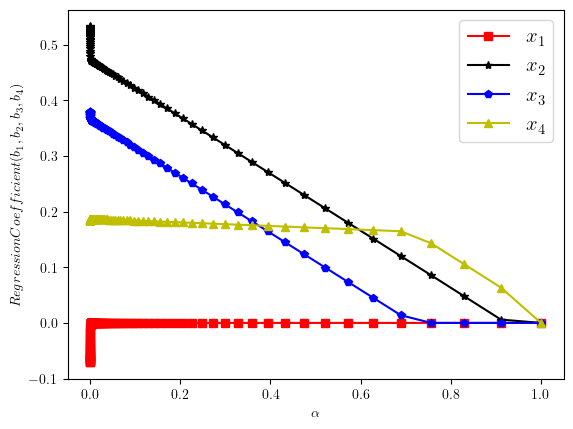

标准化数据的回归系数为: [0.         0.44723893 0.34045523 0.18555833]
原始数据的回归系数为: [-908.2058953990945, array([  0.        , 203.09384921,   1.45621116,   2.04693134])]
拟合优度为: 0.9965807211503689


In [84]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import Lasso
from scipy.stats import zscore

a = np.loadtxt("Pdata12_6.txt")
n = a.shape[1] - 1  # 自变量的个数
x = a[:, :n]  # 自变量观测值
X = sm.add_constant(x)  # 加1列全为1的元素，增广矩阵

md = sm.OLS(a[:, n], X).fit()

print(md.summary())  # 输出模型的所有结果

aa = zscore(a)  # 中心标准化
x = aa[:, :n]
y = aa[:, n]

b = []
kk = np.logspace(-4, 0, 100)

for k in kk:
    md = Lasso(alpha=k).fit(x, y)
    b.append(md.coef_)
    
st = ['s-r', '*-k', 'p-b', '^-y']
plt.rcParams['text.usetex'] = True

for i in range(n):
    plt.plot(kk, np.array(b)[:, i], st[i])
plt.legend(['$x_1$', '$x_2$', '$x_3$', '$x_4$'], fontsize=15)
plt.xlabel(r'$\alpha$')
plt.ylabel('$Regression Coefficient(b_1, b_2, b_3, b_4)$')
plt.show()

md0 = Lasso(alpha=0.05).fit(x, y)
cs0 = md0.coef_
print(f"标准化数据的回归系数为: {cs0}")

mu = np.mean(a, axis=0)
s = np.std(a, axis=0, ddof=1)

params = [mu[-1] - s[-1] * sum(cs0 * mu[:-1] / s[:-1]), s[-1] * cs0 / s[:-1]]

print(f"原始数据的回归系数为: {params}")
print(f"拟合优度为: {md0.score(x, y)}")